In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from pathlib import Path
from aux import zero_pad, format_plot
import os 

print(os.getcwd())

plt.rcParams['font.family'] = 'Helvetica'

/mmfs1/gscratch/labfairhall/davidgbe/cont_attractor


In [27]:
# ── Set directory paths here ──────────────────────────────────────────────────
DATA_PATHS = [
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_freeze_000_1.0_frozen_0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-22_00:05:22.073526_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_freeze_025_1.0_frozen_25_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-22_00:04:31.745356_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_freeze_050_1.0_frozen_50_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-22_00:06:23.348571_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_freeze_075_1.0_frozen_75_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-22_00:07:05.542722_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_freeze_100_1.0_frozen_100_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-22_00:05:15.515018_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_freeze_125_1.0_frozen_125_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-22_00:05:15.201356_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_freeze_150_1.0_frozen_150_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-22_00:06:23.350542_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_freeze_175_1.0_frozen_175_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-22_00:06:23.351395_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_freeze_200_1.0_frozen_200_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-22_00:05:14.011945_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_freeze_225_1.0_frozen_225_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-22_00:05:12.726385_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_freeze_250_1.0_frozen_250_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-22_00:05:16.518702_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_freeze_275_1.0_frozen_275_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-22_00:05:12.021441_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_freeze_300_1.0_frozen_300_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-22_00:05:11.988678_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_freeze_325_1.0_frozen_325_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-22_00:05:39.392011_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_freeze_350_1.0_frozen_350_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-22_00:05:43.738271_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_freeze_375_1.0_frozen_375_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-22_00:05:43.738286_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_freeze_400_1.0_frozen_400_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-22_00:05:43.738295_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_freeze_500_1.0_frozen_500_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-04-22_00:05:43.738296_run_None',
]

In [28]:
def load_r2_group(df):
    rule_path = Path(df) / 'scores'
    arr = np.array([np.load(f) for f in sorted((rule_path).glob('*.npy'))])
    return arr


def plot_r2(data_paths, x, labels=None, ylim=(0, 1), figsize=None):
    n = len(data_paths)
    if figsize is None:
        figsize = (max(3, 4), 2)
    if labels is None:
        labels = x

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    for i, dp in enumerate(data_paths):
        scores = load_r2_group(dp)
        ax.scatter(
            [x[i]] * len(scores), scores,
            alpha=0.3, facecolor='none', edgecolor='black', s=40,
        )
        print(f'{labels[i]}: mean={np.mean(scores):.3f} +/- {np.std(scores):.3f}  (n={len(scores)})')

    ax.set_ylim(*ylim)
    # ax.set_xticks(np.arange(n))
    # ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(r'$R^2$')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    format_plot(ax)
    plt.tight_layout()
    return fig, ax

0: mean=-0.044 +/- 0.078  (n=10)
25: mean=0.175 +/- 0.189  (n=10)
50: mean=0.296 +/- 0.172  (n=10)
75: mean=0.429 +/- 0.145  (n=10)
100: mean=0.581 +/- 0.123  (n=10)
125: mean=0.634 +/- 0.114  (n=10)
150: mean=0.740 +/- 0.115  (n=10)
175: mean=0.771 +/- 0.048  (n=10)
200: mean=0.724 +/- 0.074  (n=10)
225: mean=0.757 +/- 0.064  (n=10)
250: mean=0.739 +/- 0.127  (n=10)
275: mean=0.766 +/- 0.078  (n=10)
300: mean=0.757 +/- 0.048  (n=10)
325: mean=0.732 +/- 0.067  (n=10)
350: mean=0.719 +/- 0.072  (n=10)
375: mean=0.782 +/- 0.044  (n=10)
400: mean=0.770 +/- 0.042  (n=10)
500: mean=0.788 +/- 0.051  (n=10)


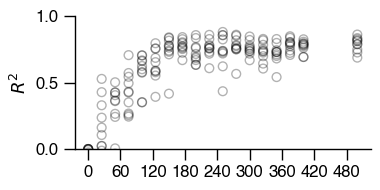

In [29]:
fig, ax = plot_r2(DATA_PATHS, np.concatenate([np.arange(0, 401, 25), np.array([500])]))
plt.show()

In [30]:
# ── Set directory paths here ──────────────────────────────────────────────────
DATA_PATHS = [
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_freeze_000_1.0_frozen_0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-05-03_18:22:33.220736_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_freeze_025_1.0_frozen_25_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-05-03_18:22:33.226880_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_freeze_050_1.0_frozen_50_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-05-03_18:22:33.232238_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_freeze_075_1.0_frozen_75_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-05-03_18:22:33.232244_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_freeze_100_1.0_frozen_100_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-05-03_18:22:33.232227_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_freeze_125_1.0_frozen_125_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-05-03_18:22:33.232261_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_freeze_150_1.0_frozen_150_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-05-03_18:22:33.232236_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_freeze_175_1.0_frozen_175_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-05-03_18:22:33.231843_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_freeze_200_1.0_frozen_200_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-05-03_18:22:33.231061_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_freeze_225_1.0_frozen_225_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-05-03_18:22:33.231075_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_freeze_250_1.0_frozen_250_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-05-03_18:22:33.231070_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_freeze_275_1.0_frozen_275_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-05-03_18:22:33.231069_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_freeze_300_1.0_frozen_300_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-05-03_18:22:33.231900_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_freeze_325_1.0_frozen_325_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-05-03_18:22:33.231914_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_freeze_350_1.0_frozen_350_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-05-03_18:22:33.227670_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_freeze_375_1.0_frozen_375_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-05-03_18:22:33.227661_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_freeze_400_1.0_frozen_400_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-05-03_18:22:33.237483_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_freeze_500_1.0_frozen_500_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-05-03_18:22:33.237479_run_None',
]

0: mean=-0.064 +/- 0.056  (n=10)
25: mean=-0.034 +/- 0.055  (n=10)
50: mean=-0.025 +/- 0.022  (n=10)
75: mean=-0.022 +/- 0.033  (n=10)
100: mean=-0.007 +/- 0.008  (n=10)
125: mean=-0.023 +/- 0.026  (n=10)
150: mean=-0.021 +/- 0.025  (n=10)
175: mean=-0.023 +/- 0.041  (n=10)
200: mean=-0.026 +/- 0.029  (n=10)
225: mean=-0.038 +/- 0.038  (n=10)
250: mean=-0.025 +/- 0.030  (n=10)
275: mean=-0.042 +/- 0.084  (n=10)
300: mean=0.000 +/- 0.026  (n=10)
325: mean=-0.246 +/- 0.442  (n=10)
350: mean=0.046 +/- 0.398  (n=9)
375: mean=0.213 +/- 0.297  (n=10)
400: mean=0.691 +/- 0.058  (n=10)
500: mean=0.897 +/- 0.016  (n=10)


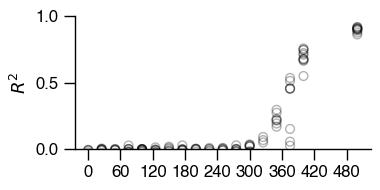

In [31]:
fig, ax = plot_r2(DATA_PATHS, np.concatenate([np.arange(0, 401, 25), np.array([500])]))
plt.show()